# Survey-like data and pycorr interoperability

This notebook shows the `pyfcfc.sky` component (FCFC_2PT):

* ingest {RA, Dec, redshift} catalogues and convert them internally with a
  fiducial cosmology (`convert=True`);
* the line-of-sight convention is the **pair midpoint** (pycorr:
  `los='midpoint'`);
* convert pyfcfc pair counts into a **pycorr state**, so the whole pycorr
  analysis stack (estimators, rebinning, saving) can be used on top of
  FCFC's fast counting.

Cross-checks against pycorr/Corrfunc agree to machine precision.

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
sys.path.insert(0, os.path.join(os.path.abspath(''), 'examples'))
sys.path.insert(0, os.path.join(os.path.abspath(''), os.pardir, 'examples'))
%matplotlib inline

from pyfcfc.sky import py_compute_cf
from pyfcfc.utils import pairs_to_pycorr, compute_multipoles
from mocks import make_survey, rdd_to_xyz

OpenBLAS WARNING - could not determine the L2 cache size on this system, assuming 256k


In [2]:
OM, OL, W = 0.31, 0.69, -1.0
rdd, w, nz = make_survey(20000, seed=43)
rdd_r, w_r, _ = make_survey(40000, seed=9, clustered=False)
print('data columns: RA [deg], Dec [deg], z ->', rdd.shape)

data columns: RA [deg], Dec [deg], z -> (20000, 3)


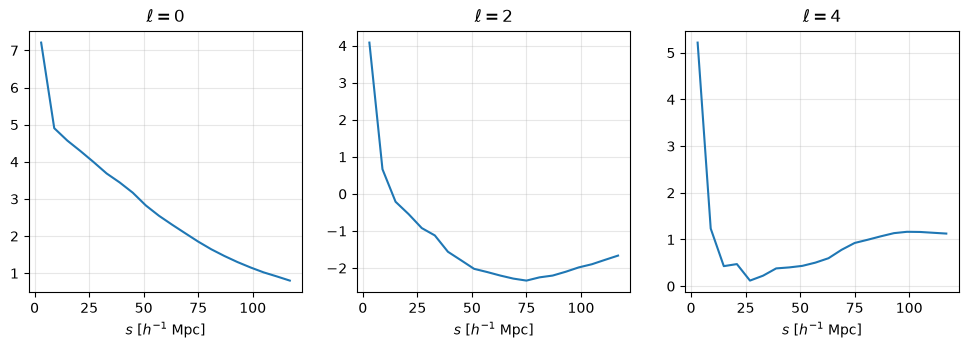

In [3]:
s_edges = np.arange(0, 121, 6.)
fc = py_compute_cf([rdd, rdd_r], [w, w_r], s_edges, None, 40,
                   label=['D', 'R'], bin=1, pair=['DD', 'DR', 'RR'],
                   cf=['(DD - 2 * DR + RR) / RR'], multipole=[0, 2, 4],
                   convert=True, omega_m=OM, omega_l=OL, eos_w=W)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharex=True)
for i, ell in enumerate((0, 2, 4)):
    axes[i].plot(fc['s'], fc['multipoles'][0, i])
    axes[i].set_title(f'$\ell={ell}$'); axes[i].grid(alpha=.3)
    axes[i].set_xlabel(r'$s$ [$h^{-1}$ Mpc]')

## Cross-check with pycorr

pycorr needs Cartesian coordinates: we convert with the *same* fiducial
cosmology (`mocks.rdd_to_xyz`) and use `los='midpoint'`, the convention of
FCFC's survey-like component.

In [4]:
from pycorr import TwoPointCorrelationFunction
xyz, xyz_r = rdd_to_xyz(rdd, OM, OL, W), rdd_to_xyz(rdd_r, OM, OL, W)
mu_edges = np.linspace(-1, 1, 81)
corr = TwoPointCorrelationFunction('smu', (s_edges, mu_edges),
    data_positions1=xyz.T, data_weights1=w,
    randoms_positions1=xyz_r.T, randoms_weights1=w_r,
    position_type='xyz', los='midpoint', estimator='landyszalay',
    engine='corrfunc', compute_sepsavg=False)
for i, ell in enumerate((0, 2, 4)):
    d = np.max(np.abs(fc['multipoles'][0, i] - corr(ell=ell)))
    print(f'max |pyfcfc - pycorr| xi_{ell} (midpoint rule): {d:.2e}')
mp_exact = compute_multipoles(fc['cf'][0], [0, 2, 4], method='exact', ignore_nan=True)
for i, ell in enumerate((0, 2, 4)):
    d = np.max(np.abs(mp_exact[i] - corr(ell=ell)))
    print(f'max |pyfcfc - pycorr| xi_{ell} (exact integration): {d:.2e}')

OpenBLAS WARNING - could not determine the L2 cache size on this system, assuming 256k


max |pyfcfc - pycorr| xi_0 (midpoint rule): 1.33e-12
max |pyfcfc - pycorr| xi_2 (midpoint rule): 2.82e-03
max |pyfcfc - pycorr| xi_4 (midpoint rule): 2.36e-02
max |pyfcfc - pycorr| xi_0 (exact integration): 1.33e-12
max |pyfcfc - pycorr| xi_2 (exact integration): 3.30e-12
max |pyfcfc - pycorr| xi_4 (exact integration): 4.47e-12


## pycorr state: save, load, rebin

`pairs_to_pycorr` maps pyfcfc pair counts onto pycorr's internal state
(mirroring the $|\mu|$ counts onto pycorr's full $[-1,1]$ range). The
result can be saved and manipulated with the standard pycorr API.

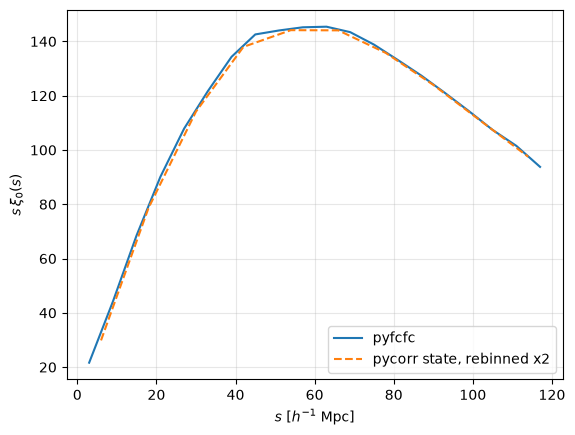

In [5]:
state = pairs_to_pycorr(fc, 'landyszalay',
                        dict(DD='D1D2', DR=('D1R2', 'R1D2'), RR='R1R2'))
import tempfile
fname = os.path.join(tempfile.mkdtemp(), 'pyfcfc_state.pkl.npy')
np.save(fname, state)
loaded = TwoPointCorrelationFunction.load(fname)
reb = loaded[::2, ::2]
s_reb, xi0_reb = reb(ell=0, return_sep=True)
plt.plot(fc['s'], fc['s']*fc['multipoles'][0, 0], label='pyfcfc')
plt.plot(s_reb, s_reb*xi0_reb, '--', label='pycorr state, rebinned x2')
plt.xlabel(r'$s$ [$h^{-1}$ Mpc]'); plt.ylabel(r'$s\,\xi_0(s)$')
plt.legend(); plt.grid(alpha=.3)
os.remove(fname)

That's it — pair counting with FCFC speed, analysis with the pycorr API.
See `examples/example_pycorr_interop.py` for the split-random accumulation
workflow used in real survey measurements.